# Análise Exploratória de Dados — Consumo de Energia (Sines)

**Objetivo:** caracterizar o consumo de energia elétrica em **Sines (código postal 7520)** e relacioná-lo
com o consumo, produção e injeção de energia a nível nacional.

**Dados (públicos, E-REDES):**
- `data/codigos_postais/*.xlsx` — consumo horário por código postal (incluindo 7520 — Sines)
- `data/consumo-total-nacional.xlsx` — consumo total nacional (kWh)
- `data/energia-injetada-na-rede-de-distribuicao.xlsx` — energia injetada na rede
- `data/energia-produzida-total-nacional.xlsx` — produção nacional (Eólica, Hídrica, Fotovoltaica, ...)

> **Nota sobre escalas:** o consumo de **Sines** é da ordem de poucos MWh/hora,
> enquanto o **consumo nacional** está na ordem dos GWh/hora.
> Por isso, gráficos comparativos usam **dois eixos Y (twin axis)** ou **normalização**.

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Estilo gráfico moderno e legível
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)
print("Diretório de dados:", os.path.abspath(DATA_DIR))

Diretório de dados: c:\Users\sofia\Downloads\Energia_Sines\data


## 1. Carregar consumo por código postal

Os ficheiros vêm da E-REDES com colunas:
`Data/Hora`, `Código Postal`, `Energia ativa (kWh)`, `Dia`, `Hora`, `Dia da Semana`.

> Aqui colocamos **todos os ficheiros .xlsx** dos códigos postais numa subpasta
> `data/codigos_postais/`. Se preferires, podes colocá-los diretamente em `data/`
> e ajustar o caminho `PASTA_CP`.

In [2]:
PASTA_CP = os.path.join(DATA_DIR, "codigos_postais")

# Fallback: se a subpasta não existir, usa todos os .xlsx que estão em data/ excepto os 3 ficheiros nacionais
ficheiros_nacionais = {
    "consumo-total-nacional.xlsx",
    "energia-injetada-na-rede-de-distribuicao.xlsx",
    "energia-produzida-total-nacional.xlsx",
}

if os.path.isdir(PASTA_CP):
    arquivos = [os.path.join(PASTA_CP, f) for f in os.listdir(PASTA_CP) if f.endswith(".xlsx")]
else:
    arquivos = [
        os.path.join(DATA_DIR, f)
        for f in os.listdir(DATA_DIR)
        if f.endswith(".xlsx") and f not in ficheiros_nacionais
    ]

print(f"Encontrados {len(arquivos)} ficheiros de códigos postais.")
arquivos[:5]

Encontrados 13 ficheiros de códigos postais.


['data\\codigos_postais\\consumos_horario_codigo_postal (1).xlsx',
 'data\\codigos_postais\\consumos_horario_codigo_postal (10).xlsx',
 'data\\codigos_postais\\consumos_horario_codigo_postal (11).xlsx',
 'data\\codigos_postais\\consumos_horario_codigo_postal (12).xlsx',
 'data\\codigos_postais\\consumos_horario_codigo_postal (2).xlsx']

In [3]:
dfs = []
for caminho in arquivos:
    try:
        d = pd.read_excel(caminho)
        dfs.append(d)
    except Exception as e:
        print(f"Erro a ler {caminho}: {e}")

df_codigo = pd.concat(dfs, ignore_index=True)
print("Shape consumo por código postal (long):", df_codigo.shape)
df_codigo.head()

Shape consumo por código postal (long): (104208, 6)


,Data/Hora,Data,Hora,Código Postal,Energia ativa (kWh),Dia da Semana
0,2023-08-28T02:00:00+01:00,2023-08-28,02:00,7520,43624.962664,Segunda
1,2022-12-05T02:00:00+00:00,2022-12-05,02:00,7520,37692.039827,Segunda
2,2023-04-16T23:00:00+01:00,2023-04-16,23:00,7520,69399.049981,Domingo
3,2023-03-22T09:00:00+00:00,2023-03-22,09:00,7520,52462.004788,Quarta
4,2023-05-29T15:00:00+01:00,2023-05-29,15:00,7520,50489.304659,Segunda


In [5]:
# Manter apenas as colunas relevantes e converter para datetime
df_codigo = df_codigo[["Data/Hora", "Código Postal", "Energia ativa (kWh)"]].copy()

# SOLUÇÃO: Adicionar utc=True aqui
df_codigo["Data/Hora"] = pd.to_datetime(df_codigo["Data/Hora"], errors="coerce", utc=True)

df_codigo["Energia ativa (kWh)"] = pd.to_numeric(df_codigo["Energia ativa (kWh)"], errors="coerce")

# Diagnóstico de qualidade
print("Valores em falta por coluna:\n", df_codigo.isna().sum())
print("\nPeríodo:", df_codigo["Data/Hora"].min(), "->", df_codigo["Data/Hora"].max())
print("Códigos postais únicos:", sorted(df_codigo["Código Postal"].unique()))

Valores em falta por coluna:
 Data/Hora              0
Código Postal          0
Energia ativa (kWh)    0
dtype: int64

Período: 2022-11-01 00:00:00+00:00 -> 2023-09-30 22:00:00+00:00
Códigos postais únicos: [np.int64(2800), np.int64(2830), np.int64(2860), np.int64(2870), np.int64(2890), np.int64(2900), np.int64(2950), np.int64(2970), np.int64(7520), np.int64(7570), np.int64(7580)]


In [6]:
# Pivot wide: uma coluna por código postal.
# Importante: aggfunc='mean' (caso haja duplicados) e SEM fill_value (preservar NaN para diagnóstico)
df_codigo_pivot = (
    df_codigo
    .pivot_table(index="Data/Hora", columns="Código Postal",
                 values="Energia ativa (kWh)", aggfunc="mean")
    .sort_index()
)
df_codigo_pivot.columns = [int(c) for c in df_codigo_pivot.columns]
df_codigo_pivot = df_codigo_pivot.reindex(columns=sorted(df_codigo_pivot.columns))

print("Shape (wide):", df_codigo_pivot.shape)
print("\n% de NaN por código postal:")
print((df_codigo_pivot.isna().mean() * 100).round(2))

df_codigo_pivot.head()

Shape (wide): (8015, 11)

% de NaN por código postal:
2800    0.0
2830    0.0
2860    0.0
2870    0.0
2890    0.0
2900    0.0
2950    0.0
2970    0.0
7520    0.0
7570    0.0
7580    0.0
dtype: float64


,2800,2830,2860,2870,2890,2900,2950,2970,7520,7570,7580
Data/Hora,,,,,,,,,,,
2022-11-01 00:00:00+00:00,5109.779921,10990.742013,6201.481659,11668.060624,6034.435379,15247.091894,19649.659297,7733.532916,42046.033643,5596.306753,3780.517860
2022-11-01 01:00:00+00:00,4591.468998,10078.955007,5564.314831,10355.814479,5363.038787,14507.985441,16409.190384,7214.730886,41742.473815,4964.724809,3042.015709
2022-11-01 02:00:00+00:00,4267.480690,9308.232646,5057.157748,9527.824206,4889.066972,13709.572218,15628.213780,6726.972889,41438.503268,4605.843696,2870.714626
2022-11-01 03:00:00+00:00,4053.564630,8846.268852,4852.545551,9029.509161,4563.878518,13492.328350,14933.132659,6526.176994,40807.048907,4451.272329,2659.751963
2022-11-01 04:00:00+00:00,3935.771983,8658.700199,4676.424890,8916.174082,4455.281847,13459.428224,14725.247986,6306.124798,40675.870346,4445.027183,2630.999943


## 2. Carregar consumo total nacional

In [9]:
df_consumo = pd.read_excel(os.path.join(DATA_DIR, "consumo-total-nacional.xlsx"))
df_consumo = df_consumo.drop(columns=["Dia", "Mês", "Ano", "Data", "Hora"], errors="ignore")

# SOLUÇÃO: Adicionar utc=True aqui
df_consumo["Data/Hora"] = pd.to_datetime(df_consumo["Data/Hora"], errors="coerce", utc=True)

df_consumo = df_consumo.rename(columns={"Total (kWh)": "Total_Consumido_kWh"})
print(df_consumo.shape)
df_consumo.head()

(101101, 6)


,Data/Hora,Baixa Tensão (kWh),Média Tensão (kWh),Alta Tensão (kWh),Muito Alta Tensão (kWh),Total_Consumido_kWh
0,2023-01-01 16:30:00+00:00,8.331705e+05,234461.2596,142883.4228,28303.5885,1.238819e+06
1,2023-01-03 02:45:00+00:00,5.922436e+05,334852.3935,174219.0454,86368.0189,1.187683e+06
2,2023-01-06 18:00:00+00:00,1.142279e+06,573648.6258,208413.7223,41613.6294,1.965955e+06
3,2023-05-16 09:15:00+00:00,6.678893e+05,578589.2644,188064.5709,84284.3365,1.518828e+06
4,2023-05-17 18:00:00+00:00,7.361484e+05,537428.3819,207317.2202,45397.2388,1.526291e+06


## 3. Carregar energia injetada na rede

In [11]:
df_injetada = pd.read_excel(os.path.join(DATA_DIR, "energia-injetada-na-rede-de-distribuicao.xlsx"))
df_injetada = df_injetada.drop(columns=["Dia", "Mês", "Ano", "Data", "Hora"], errors="ignore")

# Adicione o utc=True aqui para prevenir problemas!
df_injetada["Data/Hora"] = pd.to_datetime(df_injetada["Data/Hora"], errors="coerce", utc=True)

print(df_injetada.shape)
df_injetada.head()

(101293, 7)


,Data/Hora,Cogeração (kWh),Eólica (kWh),Fotovoltaica (kWh),Hídrica (kWh),Outras Tecnologias (kWh),Rede Distribuição (kWh)
0,2025-05-19 23:15:00+00:00,47812.436,217112.900,33.75,24580.50,31388.783,320928.369
1,2025-05-19 23:45:00+00:00,47157.640,195750.350,28.75,24592.00,32377.796,299906.536
2,2025-05-20 01:30:00+00:00,43661.660,157812.700,9.00,24424.75,32628.869,258536.979
3,2025-05-20 02:15:00+00:00,43888.020,146622.500,11.75,24808.25,31659.564,246990.084
4,2025-05-20 03:00:00+00:00,43763.698,139976.225,13.00,24330.75,31862.681,239946.354


## 4. Carregar energia produzida (mix energético nacional)

In [13]:
df_produzida = pd.read_excel(os.path.join(DATA_DIR, "energia-produzida-total-nacional.xlsx"))
df_produzida = df_produzida.drop(columns=["Dia", "Mês", "Ano", "Data", "Hora"], errors="ignore")

# SOLUÇÃO: Adicionado utc=True para uniformizar o fuso horário
df_produzida["Data/Hora"] = pd.to_datetime(df_produzida["Data/Hora"], errors="coerce", utc=True)

# Opcional: Converter para a hora de Lisboa, caso tenha feito o mesmo nos outros DataFrames
# df_produzida["Data/Hora"] = df_produzida["Data/Hora"].dt.tz_convert('Europe/Lisbon')

df_produzida = df_produzida.rename(columns={"Total (kWh)": "Total_Produzido_kWh"})
print(df_produzida.shape)
df_produzida.head()

(101293, 4)


,Data/Hora,Mercado (kWh),Regime Especial (kWh),Total_Produzido_kWh
0,2023-01-01 03:00:00+00:00,-43152,1061106.25,1017954.25
1,2023-01-01 04:45:00+00:00,-131126,1082523.00,951397.00
2,2023-01-01 07:45:00+00:00,-71598,981386.50,909788.50
3,2023-01-01 13:30:00+00:00,155345,1161023.25,1316368.25
4,2023-01-02 02:00:00+00:00,689810,296380.50,986190.50


## 5. Junção dos 4 datasets

Usamos `merge` em `Data/Hora` (chave horária). **Mantemos os NaN visíveis** para inspeção.

In [14]:
# Garantir mesmo tipo de datetime em todos
for d in (df_codigo_pivot, df_consumo, df_injetada, df_produzida):
    if d.index.name == "Data/Hora":
        d.index = pd.to_datetime(d.index)

df_codigo_pivot_reset = df_codigo_pivot.reset_index()

df_merged = (
    df_codigo_pivot_reset
    .merge(df_consumo, on="Data/Hora", how="inner")
    .merge(df_injetada, on="Data/Hora", how="inner")
    .merge(df_produzida, on="Data/Hora", how="inner")
    .sort_values("Data/Hora")
    .reset_index(drop=True)
)

print("Shape final:", df_merged.shape)
print("Período:", df_merged["Data/Hora"].min(), "->", df_merged["Data/Hora"].max())
df_merged.head()

Shape final: (6558, 26)
Período: 2023-01-01 00:00:00+00:00 -> 2023-09-30 22:00:00+00:00


,Data/Hora,2800,2830,2860,2870,2890,2900,2950,2970,7520,...,Total_Consumido_kWh,Cogeração (kWh),Eólica (kWh),Fotovoltaica (kWh),Hídrica (kWh),Outras Tecnologias (kWh),Rede Distribuição (kWh),Mercado (kWh),Regime Especial (kWh),Total_Produzido_kWh
0,2023-01-01 00:00:00+00:00,5979.944815,12573.029702,7304.442240,12217.464423,6256.521612,12713.512023,13613.251250,9860.900749,45501.800240,...,1.168971e+06,0.75,829883.50,0.25,51521.75,59767.50,941173.75,227797,941173.75,1168970.75
1,2023-01-01 01:00:00+00:00,5541.143249,11783.036428,6658.256518,11508.811881,5874.434895,12292.945092,12905.606706,9281.662624,45170.849644,...,1.129887e+06,0.25,858150.25,0.25,51575.75,60743.75,970470.25,159417,970470.25,1129887.25
2,2023-01-01 02:00:00+00:00,5089.677488,10736.926634,6069.046860,10621.505510,5500.324143,11677.278318,11985.418301,8689.977490,44743.436723,...,1.080060e+06,0.75,896699.75,0.00,51599.00,59171.25,1007470.75,72589,1007470.75,1080059.75
3,2023-01-01 03:00:00+00:00,4722.338149,10151.333371,5643.222472,10090.276419,5097.094133,10827.898895,11438.860714,8093.669021,44559.972174,...,1.017954e+06,0.25,950703.25,0.25,51631.50,58771.00,1061106.25,-43152,1061106.25,1017954.25
4,2023-01-01 04:00:00+00:00,4482.776559,9606.734157,5205.407472,9493.696796,4855.284882,9382.840972,11003.473134,7539.944635,44454.468574,...,9.764127e+05,0.25,1044171.75,0.00,51218.00,56422.75,1151812.75,-175400,1151812.75,976412.75


In [15]:
# Diagnóstico de valores em falta no dataset combinado
nan_pct = (df_merged.isna().mean() * 100).round(2).sort_values(ascending=False)
print("% de NaN por coluna (top 15):")
print(nan_pct.head(15))

% de NaN por coluna (top 15):
Data/Hora             0.0
2800                  0.0
2830                  0.0
2860                  0.0
2870                  0.0
2890                  0.0
2900                  0.0
2950                  0.0
2970                  0.0
7520                  0.0
7570                  0.0
7580                  0.0
Baixa Tensão (kWh)    0.0
Média Tensão (kWh)    0.0
Alta Tensão (kWh)     0.0
dtype: float64


In [16]:
# Tratamento de NaN nas séries horárias:
# - Para Sines (7520) e para colunas numéricas usamos interpolação temporal (curta) e depois ffill/bfill
df_merged = df_merged.set_index("Data/Hora").sort_index()
num_cols = df_merged.select_dtypes(include=[np.number]).columns

df_merged[num_cols] = (
    df_merged[num_cols]
    .interpolate(method="time", limit=6)   # até 6h consecutivas
    .ffill(limit=24)
    .bfill(limit=24)
)
df_merged = df_merged.dropna(subset=[7520])  # exigimos o target válido
df_merged = df_merged.reset_index()
print("Shape após interpolação:", df_merged.shape)
print("NaN restantes:", int(df_merged.isna().sum().sum()))

Shape após interpolação: (6558, 26)
NaN restantes: 0


## 6. Variáveis de calendário

In [17]:
df_merged["Ano"]        = df_merged["Data/Hora"].dt.year
df_merged["Mês"]        = df_merged["Data/Hora"].dt.month
df_merged["Dia"]        = df_merged["Data/Hora"].dt.day
df_merged["Hora"]       = df_merged["Data/Hora"].dt.hour
df_merged["Dia_Semana"] = df_merged["Data/Hora"].dt.dayofweek   # 0=Seg ... 6=Dom
df_merged["Semana"]     = df_merged["Data/Hora"].dt.isocalendar().week.astype(int)

df_merged.head()

,Data/Hora,2800,2830,2860,2870,2890,2900,2950,2970,7520,...,Rede Distribuição (kWh),Mercado (kWh),Regime Especial (kWh),Total_Produzido_kWh,Ano,Mês,Dia,Hora,Dia_Semana,Semana
0,2023-01-01 00:00:00+00:00,5979.944815,12573.029702,7304.442240,12217.464423,6256.521612,12713.512023,13613.251250,9860.900749,45501.800240,...,941173.75,227797,941173.75,1168970.75,2023,1,1,0,6,52
1,2023-01-01 01:00:00+00:00,5541.143249,11783.036428,6658.256518,11508.811881,5874.434895,12292.945092,12905.606706,9281.662624,45170.849644,...,970470.25,159417,970470.25,1129887.25,2023,1,1,1,6,52
2,2023-01-01 02:00:00+00:00,5089.677488,10736.926634,6069.046860,10621.505510,5500.324143,11677.278318,11985.418301,8689.977490,44743.436723,...,1007470.75,72589,1007470.75,1080059.75,2023,1,1,2,6,52
3,2023-01-01 03:00:00+00:00,4722.338149,10151.333371,5643.222472,10090.276419,5097.094133,10827.898895,11438.860714,8093.669021,44559.972174,...,1061106.25,-43152,1061106.25,1017954.25,2023,1,1,3,6,52
4,2023-01-01 04:00:00+00:00,4482.776559,9606.734157,5205.407472,9493.696796,4855.284882,9382.840972,11003.473134,7539.944635,44454.468574,...,1151812.75,-175400,1151812.75,976412.75,2023,1,1,4,6,52


## 7. Estatística descritiva (Sines + variáveis nacionais)

> **Atenção às unidades:** todos os valores estão em **kWh**.
> Sines (7520) é um único código postal → valores pequenos.
> Total Consumido / Total Produzido são valores agregados nacionais → valores muito maiores.

In [18]:
codigos_postais_existentes = [c for c in [2800, 2830, 2860, 2870, 2890, 2900, 2950, 2970, 7520, 7570, 7580]
                              if c in df_merged.columns]

cols_resumo = codigos_postais_existentes + ["Total_Consumido_kWh", "Total_Produzido_kWh"]
df_merged[cols_resumo].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
2800,6558.0,6723.77,1680.28,1965.04,5115.77,6993.00,7844.68,12033.22
2830,6558.0,15125.65,3292.11,3809.77,12541.92,15280.14,17658.48,25569.33
2860,6558.0,9755.87,2048.05,2435.86,8241.09,9868.81,11182.03,17394.05
2870,6558.0,16562.13,3975.51,3677.60,13062.98,16819.84,19504.94,29907.74
2890,6558.0,9249.92,2230.86,2440.79,7191.82,9372.75,11023.10,15396.33
2900,6558.0,18110.02,3338.60,6938.72,15640.42,18144.53,20395.08,27928.67
2950,6558.0,28619.73,7448.64,8522.90,23101.29,28431.64,34792.78,45881.21
2970,6558.0,10272.39,2230.71,2555.70,8283.22,10492.37,11979.38,16827.57
7520,6558.0,54981.67,10329.42,23468.34,47416.44,55568.03,62928.20,79577.90
7570,6558.0,9098.10,1913.66,2310.73,7700.08,9098.48,10314.52,15555.97


## 8. Série temporal — Sines vs Nacional (dois eixos)

Como as escalas são muito diferentes, usamos **eixos Y duplos** para comparar a dinâmica.

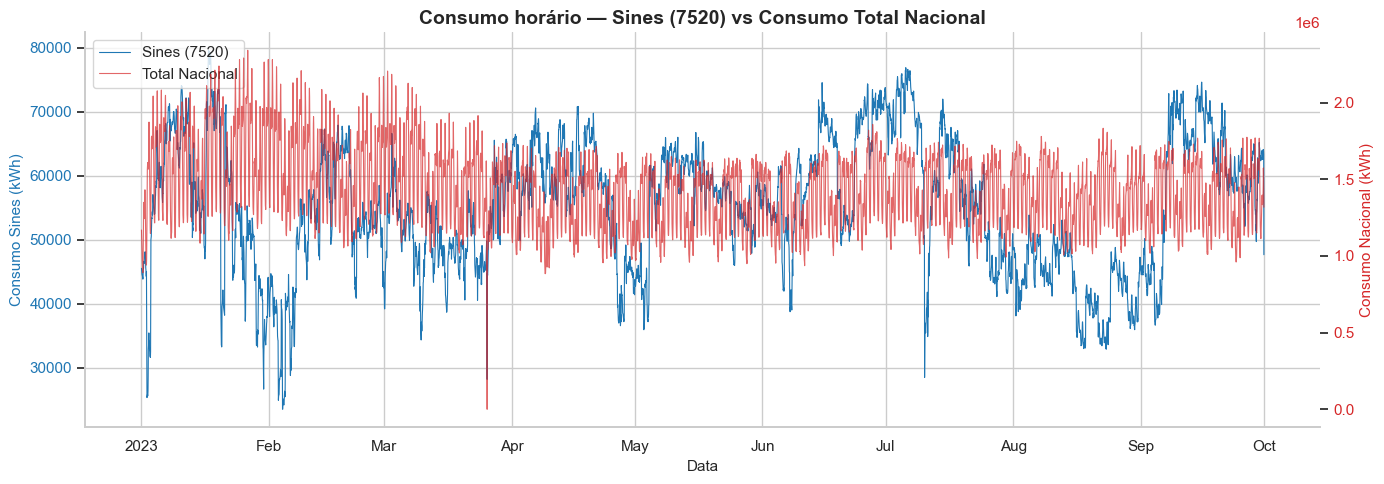

In [19]:
fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.plot(df_merged["Data/Hora"], df_merged[7520], color="#1f77b4", linewidth=0.8, label="Sines (7520)")
ax2.plot(df_merged["Data/Hora"], df_merged["Total_Consumido_kWh"], color="#d62728",
         linewidth=0.8, alpha=0.7, label="Total Nacional")

ax1.set_ylabel("Consumo Sines (kWh)", color="#1f77b4")
ax2.set_ylabel("Consumo Nacional (kWh)", color="#d62728")
ax1.tick_params(axis="y", labelcolor="#1f77b4")
ax2.tick_params(axis="y", labelcolor="#d62728")
ax1.set_xlabel("Data")
ax1.set_title("Consumo horário — Sines (7520) vs Consumo Total Nacional")
ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
ax1.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax1.xaxis.get_major_locator()))
ax2.grid(False)

# Legenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.show()

## 9. Padrão sazonal — média mensal (normalizada)

Para comparar perfis (e não magnitudes), normalizamos cada série (z-score).

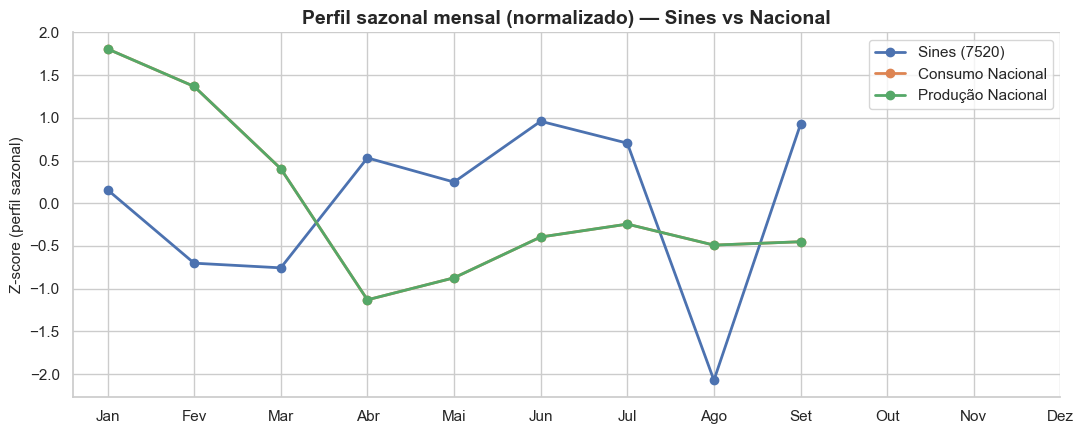

In [20]:
monthly = df_merged.groupby("Mês")[[7520, "Total_Consumido_kWh", "Total_Produzido_kWh"]].mean()
monthly_z = (monthly - monthly.mean()) / monthly.std()

fig, ax = plt.subplots(figsize=(11, 4.5))
for col, label in [(7520, "Sines (7520)"),
                   ("Total_Consumido_kWh", "Consumo Nacional"),
                   ("Total_Produzido_kWh", "Produção Nacional")]:
    ax.plot(monthly_z.index, monthly_z[col], marker="o", label=label, linewidth=2)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Fev","Mar","Abr","Mai","Jun","Jul","Ago","Set","Out","Nov","Dez"])
ax.set_ylabel("Z-score (perfil sazonal)")
ax.set_title("Perfil sazonal mensal (normalizado) — Sines vs Nacional")
ax.legend()
plt.tight_layout(); plt.show()

## 10. Perfil horário do consumo em Sines (boxplot)

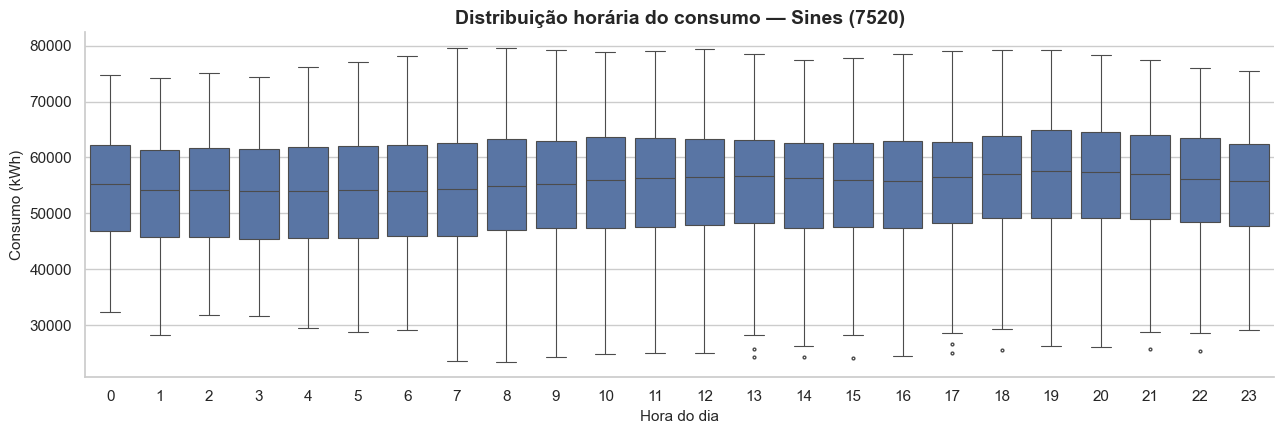

In [21]:
fig, ax = plt.subplots(figsize=(13, 4.5))
sns.boxplot(data=df_merged, x="Hora", y=7520, ax=ax,
            color="#4C72B0", fliersize=2, linewidth=0.8)
ax.set_title("Distribuição horária do consumo — Sines (7520)")
ax.set_xlabel("Hora do dia")
ax.set_ylabel("Consumo (kWh)")
plt.tight_layout(); plt.show()

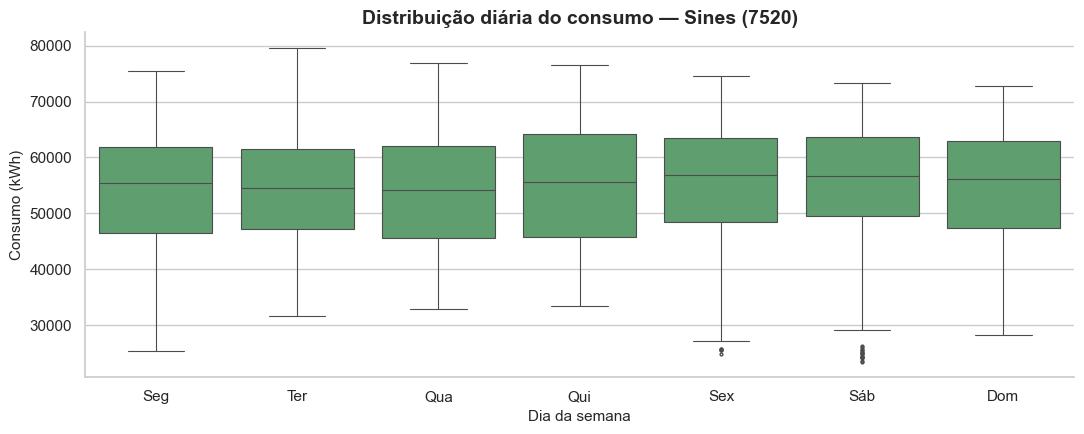

In [22]:
fig, ax = plt.subplots(figsize=(11, 4.5))
sns.boxplot(data=df_merged, x="Dia_Semana", y=7520, ax=ax,
            order=[0,1,2,3,4,5,6], color="#55A868", fliersize=2, linewidth=0.8)
ax.set_xticklabels(["Seg","Ter","Qua","Qui","Sex","Sáb","Dom"])
ax.set_title("Distribuição diária do consumo — Sines (7520)")
ax.set_xlabel("Dia da semana")
ax.set_ylabel("Consumo (kWh)")
plt.tight_layout(); plt.show()

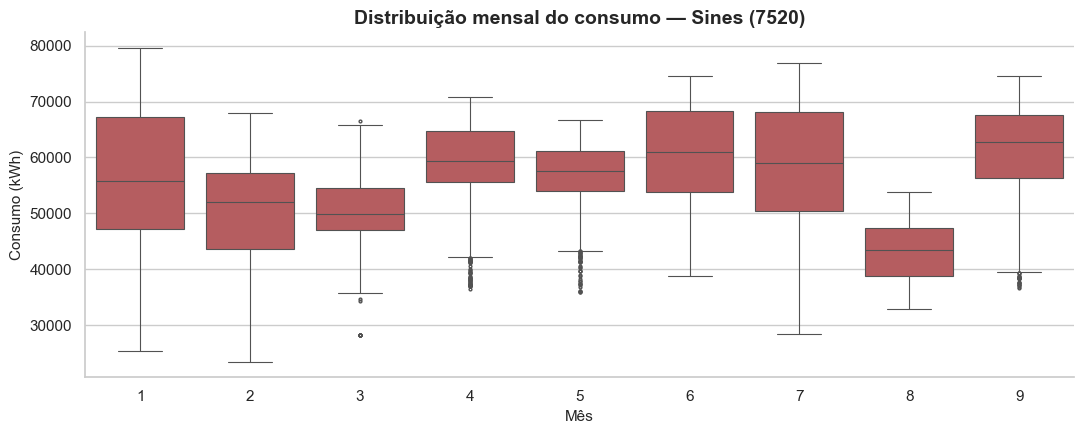

In [23]:
fig, ax = plt.subplots(figsize=(11, 4.5))
sns.boxplot(data=df_merged, x="Mês", y=7520, ax=ax,
            color="#C44E52", fliersize=2, linewidth=0.8)
ax.set_title("Distribuição mensal do consumo — Sines (7520)")
ax.set_xlabel("Mês")
ax.set_ylabel("Consumo (kWh)")
plt.tight_layout(); plt.show()

## 11. Histograma de Sines + curva de densidade

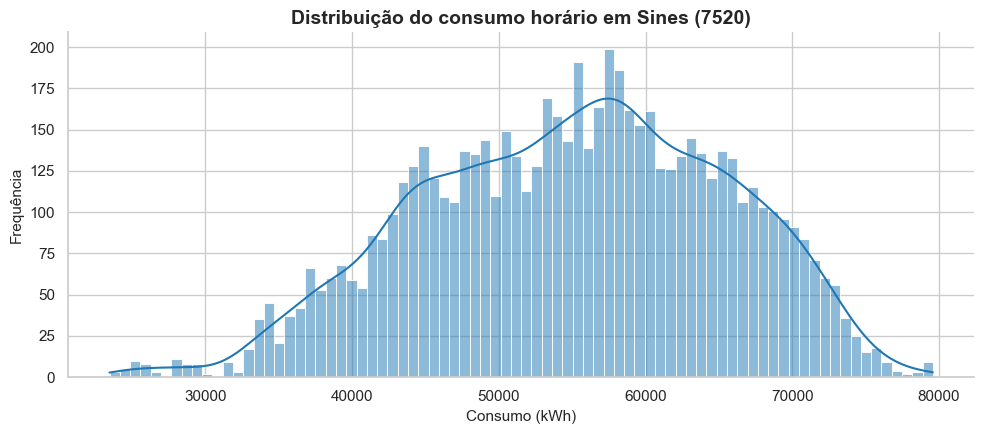

In [24]:
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.histplot(df_merged[7520], bins=80, kde=True, color="#1f77b4", ax=ax)
ax.set_title("Distribuição do consumo horário em Sines (7520)")
ax.set_xlabel("Consumo (kWh)"); ax.set_ylabel("Frequência")
plt.tight_layout(); plt.show()

## 12. Correlações entre Sines e o resto do sistema

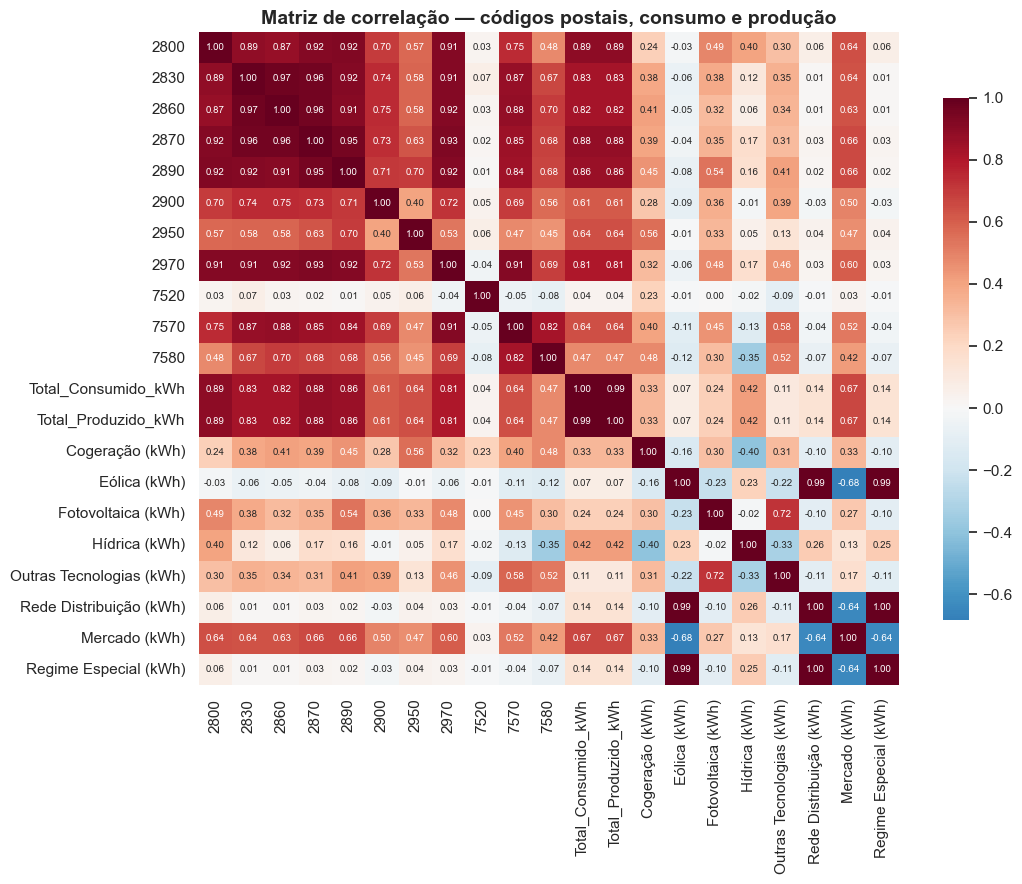


Correlações de Sines (7520) com restantes variáveis (ordenadas):
Cogeração (kWh)             0.230
2830                        0.068
2950                        0.064
2900                        0.045
Total_Produzido_kWh         0.036
Total_Consumido_kWh         0.036
Mercado (kWh)               0.034
2860                        0.030
2800                        0.027
2870                        0.021
2890                        0.014
Fotovoltaica (kWh)          0.005
Regime Especial (kWh)      -0.008
Rede Distribuição (kWh)    -0.008
Eólica (kWh)               -0.009
Hídrica (kWh)              -0.016
2970                       -0.044
7570                       -0.054
7580                       -0.081
Outras Tecnologias (kWh)   -0.092
Name: 7520, dtype: float64


In [25]:
colunas_producao = [c for c in [
    "Cogeração (kWh)", "Eólica (kWh)", "Fotovoltaica (kWh)", "Hídrica (kWh)",
    "Outras Tecnologias (kWh)", "Rede Distribuição (kWh)", "Mercado (kWh)",
    "Regime Especial (kWh)"] if c in df_merged.columns]

cols_corr = codigos_postais_existentes + ["Total_Consumido_kWh", "Total_Produzido_kWh"] + colunas_producao
corr = df_merged[cols_corr].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            annot_kws={"size": 7}, square=False, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Matriz de correlação — códigos postais, consumo e produção")
plt.tight_layout(); plt.show()

print("\nCorrelações de Sines (7520) com restantes variáveis (ordenadas):")
print(corr[7520].drop(7520).sort_values(ascending=False).round(3))

## 13. Outliers — diagnóstico (sem remoção agressiva)

Em vez de descartar via z-score, **inspecionamos** e marcamos.
Mantemos as observações para os modelos (LSTM/GRU/XGBoost lidam bem com picos quando há lags).

In [26]:
z = (df_merged[7520] - df_merged[7520].mean()) / df_merged[7520].std()
df_merged["Outlier_z3"] = (z.abs() > 3).astype(int)
print(f"Outliers |z|>3: {df_merged['Outlier_z3'].sum()}  ({df_merged['Outlier_z3'].mean()*100:.2f}%)")

Outliers |z|>3: 2  (0.03%)


## 14. Feature engineering para modelação

- **Estação do ano** (Inverno/Primavera/Verão/Outono) → one-hot
- **Fim de semana** (0/1)
- **Variáveis cíclicas** (sin/cos) para Hora, Dia da Semana e Mês

In [28]:
def obter_estacao(data):
    ano = data.year
    fuso = data.tz  # Extrai o fuso horário da data atual
    
    # Cria as datas de mudança de estação já COM o mesmo fuso horário (tz=fuso)
    prim   = pd.Timestamp(year=ano, month=3, day=21, tz=fuso)
    verao  = pd.Timestamp(year=ano, month=6, day=21, tz=fuso)
    outono = pd.Timestamp(year=ano, month=9, day=23, tz=fuso)
    inv    = pd.Timestamp(year=ano, month=12, day=21, tz=fuso)
    
    if   prim   <= data < verao:  return "Primavera"
    elif verao  <= data < outono: return "Verão"
    elif outono <= data < inv:    return "Outono"
    else:                         return "Inverno"

# O resto do seu código mantém-se igual
df_merged["Estacao"] = df_merged["Data/Hora"].apply(obter_estacao)
df_merged = pd.get_dummies(df_merged, columns=["Estacao"], prefix="Estacao", dtype=int)
df_merged["Fim_de_Semana"] = df_merged["Dia_Semana"].isin([5, 6]).astype(int)

# Cíclicas
df_merged["Hora_sin"]       = np.sin(2*np.pi*df_merged["Hora"]/24)
df_merged["Hora_cos"]       = np.cos(2*np.pi*df_merged["Hora"]/24)
df_merged["Dia_Semana_sin"] = np.sin(2*np.pi*df_merged["Dia_Semana"]/7)
df_merged["Dia_Semana_cos"] = np.cos(2*np.pi*df_merged["Dia_Semana"]/7)
df_merged["Mes_sin"]        = np.sin(2*np.pi*(df_merged["Mês"]-1)/12)
df_merged["Mes_cos"]        = np.cos(2*np.pi*(df_merged["Mês"]-1)/12)

df_merged.head(3)

,Data/Hora,2800,2830,2860,2870,2890,2900,2950,2970,7520,...,Estacao_Outono,Estacao_Primavera,Estacao_Verão,Fim_de_Semana,Hora_sin,Hora_cos,Dia_Semana_sin,Dia_Semana_cos,Mes_sin,Mes_cos
0,2023-01-01 00:00:00+00:00,5979.944815,12573.029702,7304.442240,12217.464423,6256.521612,12713.512023,13613.251250,9860.900749,45501.800240,...,0,0,0,1,0.000000,1.000000,-0.781831,0.62349,0.0,1.0
1,2023-01-01 01:00:00+00:00,5541.143249,11783.036428,6658.256518,11508.811881,5874.434895,12292.945092,12905.606706,9281.662624,45170.849644,...,0,0,0,1,0.258819,0.965926,-0.781831,0.62349,0.0,1.0
2,2023-01-01 02:00:00+00:00,5089.677488,10736.926634,6069.046860,10621.505510,5500.324143,11677.278318,11985.418301,8689.977490,44743.436723,...,0,0,0,1,0.500000,0.866025,-0.781831,0.62349,0.0,1.0


## 15. Guardar dataset final para os modelos

> **IMPORTANTE:** NÃO convertemos o dataframe inteiro para `int`
> (isso corromperia os valores em kWh e a coluna `Data/Hora`).
> Mantemos os tipos nativos.

In [30]:
out_path = os.path.join(DATA_DIR, "dataset_completo_sines.xlsx")

# 1. Criar uma cópia para não alterar o DataFrame original que está na memória
df_export = df_merged.copy()

# 2. Remover o fuso horário da coluna Data/Hora (torná-la tz-naive)
if isinstance(df_export["Data/Hora"].dtype, pd.DatetimeTZDtype):
    df_export["Data/Hora"] = df_export["Data/Hora"].dt.tz_localize(None)

# 3. Guardar no Excel
df_export.to_excel(out_path, index=False)

print("Guardado em:", out_path)
print("Shape:", df_export.shape)
print("Colunas:", df_export.columns.tolist())

Guardado em: data\dataset_completo_sines.xlsx
Shape: (6558, 44)
Colunas: ['Data/Hora', 2800, 2830, 2860, 2870, 2890, 2900, 2950, 2970, 7520, 7570, 7580, 'Baixa Tensão (kWh)', 'Média Tensão (kWh)', 'Alta Tensão (kWh)', 'Muito Alta Tensão (kWh)', 'Total_Consumido_kWh', 'Cogeração (kWh)', 'Eólica (kWh)', 'Fotovoltaica (kWh)', 'Hídrica (kWh)', 'Outras Tecnologias (kWh)', 'Rede Distribuição (kWh)', 'Mercado (kWh)', 'Regime Especial (kWh)', 'Total_Produzido_kWh', 'Ano', 'Mês', 'Dia', 'Hora', 'Dia_Semana', 'Semana', 'Outlier_z3', 'Estacao_Inverno', 'Estacao_Outono', 'Estacao_Primavera', 'Estacao_Verão', 'Fim_de_Semana', 'Hora_sin', 'Hora_cos', 'Dia_Semana_sin', 'Dia_Semana_cos', 'Mes_sin', 'Mes_cos']


---
### Conclusões da EDA

- O consumo em **Sines (7520)** tem forte **periodicidade horária e semanal** e variação **sazonal** marcada.
- A correlação com o **consumo total nacional** é moderada (perfil parecido, mas Sines é dominado por consumo industrial local — porto/refinaria).
- Os ficheiros de produção nacional (eólica, hídrica, etc.) trazem informação útil para o modelo.
- Não foram removidos outliers de forma agressiva — apenas marcados; LSTM/GRU lidam bem com lags.

O ficheiro `data/dataset_completo_sines.xlsx` é o input dos notebooks **02_LSTM**, **03_GRU** e **04_XGBoost**.